In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import stim

import os 

while 'honeycomb.py' not in os.listdir():
    os.chdir("..")

from honeycomb import CSSHoneycomb

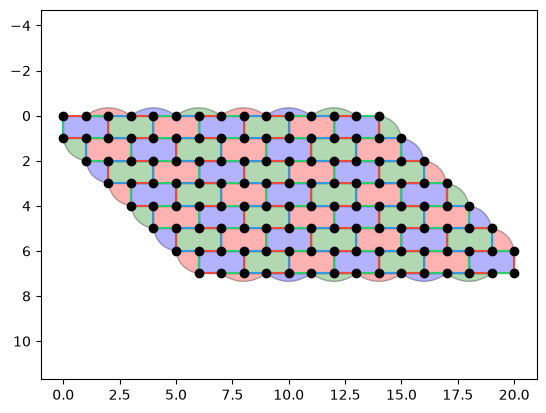

In [11]:
honey = CSSHoneycomb(ncols=15, nrows=8)
honey.plot_surface()

In [12]:
plaquettes = honey.plaquettes
p1 = [p for p in plaquettes if len(p) == 1]
print(p1)

[]


# data qubits
QUBIT_COORDS(0,0) 0
QUBIT_COORDS(1,0) 1
QUBIT_COORDS(2,0) 2
QUBIT_COORDS(3,0) 3
QUBIT_COORDS(4,0) 4
QUBIT_COORDS(5,0) 5
QUBIT_COORDS(6,0) 6
QUBIT_COORDS(7,0) 7
QUBIT_COORDS(8,0) 8
QUBIT_COORDS(9,0) 9
QUBIT_COORDS(10,0) 10
QUBIT_COORDS(11,0) 11
QUBIT_COORDS(12,0) 12
QUBIT_COORDS(13,0) 13
QUBIT_COORDS(14,0) 14
QUBIT_COORDS(0,1) 15
QUBIT_COORDS(1,1) 16
QUBIT_COORDS(2,1) 17
QUBIT_COORDS(3,1) 18
QUBIT_COORDS(4,1) 19
QUBIT_COORDS(5,1) 20
QUBIT_COORDS(6,1) 21
QUBIT_COORDS(7,1) 22
QUBIT_COORDS(8,1) 23
QUBIT_COORDS(9,1) 24
QUBIT_COORDS(10,1) 25
QUBIT_COORDS(11,1) 26
QUBIT_COORDS(12,1) 27
QUBIT_COORDS(13,1) 28
QUBIT_COORDS(14,1) 29
QUBIT_COORDS(15,1) 30
QUBIT_COORDS(1,2) 31
QUBIT_COORDS(2,2) 32
QUBIT_COORDS(3,2) 33
QUBIT_COORDS(4,2) 34
QUBIT_COORDS(5,2) 35
QUBIT_COORDS(6,2) 36
QUBIT_COORDS(7,2) 37
QUBIT_COORDS(8,2) 38
QUBIT_COORDS(9,2) 39
QUBIT_COORDS(10,2) 40
QUBIT_COORDS(11,2) 41
QUBIT_COORDS(12,2) 42
QUBIT_COORDS(13,2) 43
QUBIT_COORDS(14,2) 44
QUBIT_COORDS(15,2) 45
QUBIT_COORDS(

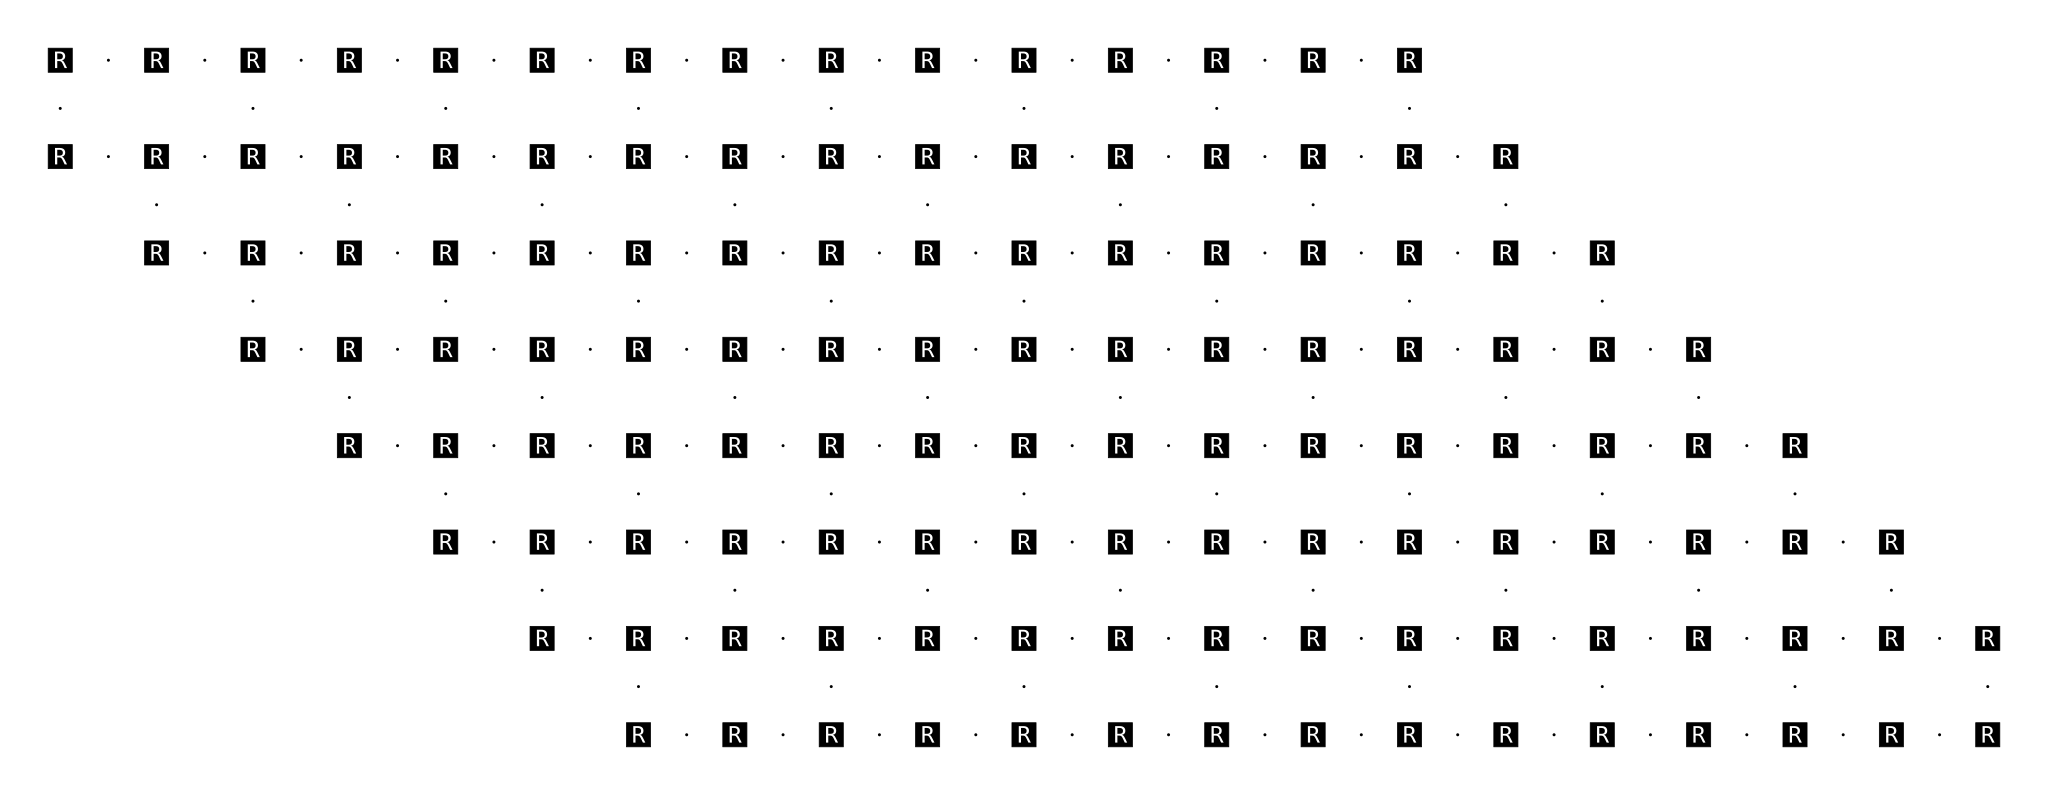

In [13]:
string = honey.initialise_circuit(coordinates='square')
string += honey.prepare_qubits()
print(string)
circuit = stim.Circuit(string)
circuit.diagram("detslice-with-ops-svg")

In [14]:
# TODO do we use letters or words?
COLOUR_MAP = {
    'r' : 'red',
    'g' : 'green',
    'b' : 'blue'
}

def measurement_cycle(honey: CSSHoneycomb, cycle=["rZ", "gX", "bZ", "rX", "gZ", "bX"]):
    """
    measure our stabilizers
    """

    string = ""
    for m in cycle:
        colour = COLOUR_MAP[m[0]]
        flavour = m[1]

        string += f"#{colour}{flavour}\n"
        string += honey.get_measurement(colour, flavour) + "\n"
        string += "tick\n"
    
    return string

print(measurement_cycle(honey, ['rXX', 'gZZ']))

#redX
# prepare ancillas in X basis
R 127 129 131 136 138 140 145 147 148 153 155 157 162 164 166 172 174 179 181 183 188 190 192 196 198 200 205 207 209 214 216 217 222 224 226 231 233 235 241 243 248 250 252 257 259 261 265 267 269 274 276 278 283 285 286 289 292 295 298 
TICK
H 127 129 131 136 138 140 145 147 148 153 155 157 162 164 166 172 174 179 181 183 188 190 192 196 198 200 205 207 209 214 216 217 222 224 226 231 233 235 241 243 248 250 252 257 259 261 265 267 269 274 276 278 283 285 286 289 292 295 298 
TICK
# fold stabilizers
CNOT 0 127 2 129 3 131 6 136 8 138 9 140 12 145 14 147 15 148 18 153 20 155 21 157 24 162 26 164 27 166 32 172 33 174 36 179 38 181 39 183 42 188 44 190 45 192 48 196 50 198 51 200 54 205 56 207 57 209 60 214 62 216 63 217 66 222 68 224 69 226 72 231 74 233 75 235 80 241 81 243 84 248 86 250 87 252 90 257 92 259 93 261 96 265 98 267 99 269 102 274 104 276 105 278 108 283 110 285 111 286 114 289 117 292 120 295 123 298 
TICK
CNOT 1 127 17 129 4 131 7 136

A full cycle looks like:

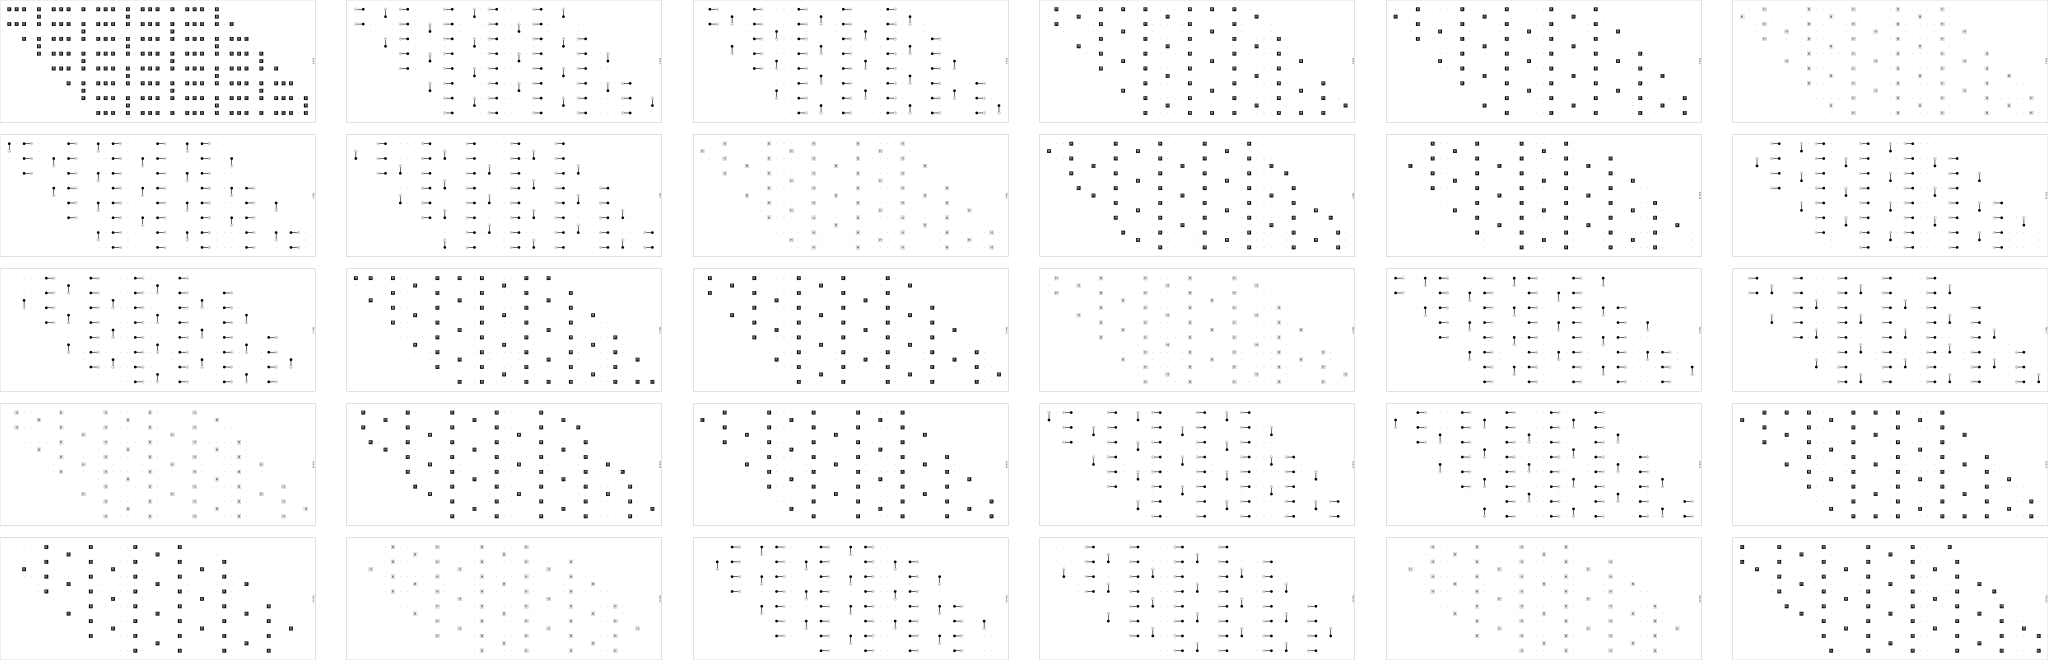

In [15]:
string = measurement_cycle(honey)
with open("testing/output/measurement_cycle.txt", "w") as f:
    f.write(string)
    
c_meas = stim.Circuit(string)
circuit += c_meas

circuit.diagram("timeslice-svg")

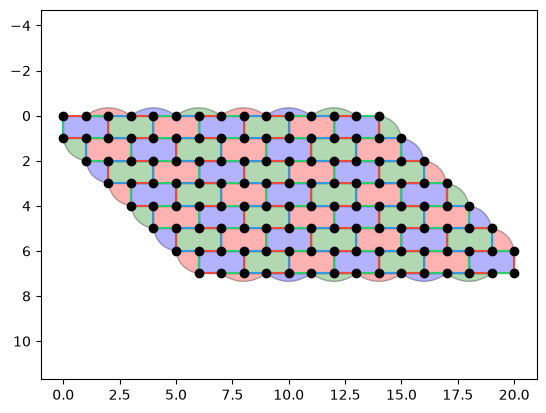

In [16]:
honey.plot_surface()